<a href="https://colab.research.google.com/github/abia200304/Python-for-ML/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Bike Rental Demand Prediction with Linear Regression

This task is to predict the hourly count of bike rentals from time and weather
features using linear regression

In [2]:
#loading of dataset
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#loading of CSV file
DATA_PATH= "/content/hour.csv"
df =pd.read_csv(DATA_PATH, on_bad_lines='skip', engine='python')

print("Dataset shape:", df.shape)
print("'\n Column name:")
print(df.columns.tolist())


Dataset shape: (17379, 17)
'
 Column name:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


In [4]:
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)



First 5 rows:
   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  

Data types:
instant         int64
dteday         object
season          int64
yr   


Binary variable=yr,holiday,working day

categorical variables=season ,weathersit

cyclic variables=hr,mnth,weekday

Continous variables=temp,atemp,hum,windspeed




In [5]:
# Summary
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
          instant        season            yr          mnth            hr  \
count  17379.0000  17379.000000  17379.000000  17379.000000  17379.000000   
mean    8690.0000      2.501640      0.502561      6.537775     11.546752   
std     5017.0295      1.106918      0.500008      3.438776      6.914405   
min        1.0000      1.000000      0.000000      1.000000      0.000000   
25%     4345.5000      2.000000      0.000000      4.000000      6.000000   
50%     8690.0000      3.000000      1.000000      7.000000     12.000000   
75%    13034.5000      3.000000      1.000000     10.000000     18.000000   
max    17379.0000      4.000000      1.000000     12.000000     23.000000   

            holiday       weekday    workingday    weathersit          temp  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.028770      3.003683      0.682721      1.425283      0.496987   
std        0.167165      2.005771      0.465431 

In [6]:
#Inspection of Categorical Variables
categorical_columns = ["season","yr","mnth","hr","holiday","weekday","workingday","weathersit"]
for col in categorical_columns:
    print(f"\n{col}:")
    print(sorted(df[col].unique()))


season:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

yr:
[np.int64(0), np.int64(1)]

mnth:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

hr:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

holiday:
[np.int64(0), np.int64(1)]

weekday:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

workingday:
[np.int64(0), np.int64(1)]

weathersit:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [9]:
#checking target distribution
#target=cnt
print("\nTarget stat:")
print(df["cnt"].describe())

print("\nNumber of unique target values:")
print(df["cnt"].nunique())#This tells us how bike rental demand is distributed.


Target stat:
count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: cnt, dtype: float64

Number of unique target values:
869


In [10]:
#checking relationship btw causal,registered and cnt
print("\nChecking target construction:")

difference= (df["casual"]+df["registered"] - df["cnt"]).abs()

print("Maximum absolute difference:",difference.max())#this tells that sum of casual and registered is cnt.So using those two columns cause target leakage


Checking target construction:
Maximum absolute difference: 0


Train-Val-Test Split

In [ ]:
#train-validation -test split
from sklearn.model_selection import train_test_split

# Features allowed for prediction
feature_columns = ["season","yr","mnth","hr", "holiday","weekday","workingday","weathersit","temp","atemp","hum","windspeed"]
target_column = "cnt"

X_raw = df[feature_columns]
y = df[target_column]
#first split 80% train,20%ctemp
X_train, X_temp, y_train, y_temp = train_test_split(X_raw, y,test_size=0.20,random_state=42) # random_state gives the same split every time.


#Second split:temporary 20% will be split as 10% validation and  10% test
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=42)

print("Training rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows:", len(X_test))

Training rows: 13903
Validation rows: 1738
Test rows: 1738


In [ ]:

# Calculating the average demand for each hour using training data only
hourly_demand =(pd.DataFrame({"hr": X_train["hr"],"cnt": y_train }).groupby("hr")["cnt"].mean().sort_values(ascending=False))

print("Average demand by hour:")
print(hourly_demand)

# Selecting the five highest-demand hours
top_5_hours =hourly_demand.head(5).index.tolist()

print("\nFive selected hours:", top_5_hours)

Average demand by hour:
hr
17    466.667797
18    420.811847
8     365.941880
16    311.720539
19    311.362393
13    258.676174
12    257.333898
15    248.154905
14    235.343805
20    229.844291
9     223.650685
7     214.332149
11    209.868739
10    177.547945
21    174.137931
22    132.163265
23     87.096055
6      74.412587
0      53.630662
1      33.211340
2      22.615646
5      19.955326
3      11.784906
4       6.413732
Name: cnt, dtype: float64

Five selected hours: [17, 18, 8, 16, 19]


In [ ]:
# def engineer_features(data, top_5_hours):

#     X =data.copy()

#     categorical_columns=["season","mnth","hr","weekday","weathersit"]

#     # One-hot encode categorical variables
#     X =pd.get_dummies(X,columns=categorical_columns,drop_first=True,dtype=float)

#     # Add the five humidity-hour interactions
#     for hour in top_5_hours:
#         X[f"hum_hr_{hour}"]=(data["hum"]* (data["hr"] ==hour).astype(float))

#     return X

In [ ]:
X_train_eng = engineer_features(X_train,top_5_hours)

In [ ]:
train_columns= X_train_eng.columns

In [ ]:
X_val_eng = engineer_features(X_val, top_5_hours)
X_test_eng = engineer_features(X_test, top_5_hours)
X_val_eng = X_val_eng.reindex(columns=train_columns,fill_value=0)
X_test_eng = X_test_eng.reindex(columns=train_columns,fill_value=0)

In [ ]:
print("Train/validation columns identical:",list(X_train_eng.columns) == list(X_val_eng.columns))

print("Train/test columns identical:",list(X_train_eng.columns) == list(X_test_eng.columns))

Train/validation columns identical: True
Train/test columns identical: True


In [ ]:
print("Training feature matrix shape:", X_train_eng.shape)
print("Validation feature matrix shape:", X_val_eng.shape)
print("Test feature matrix shape:", X_test_eng.shape)

print("\nNumber of predictor columns:",
      X_train_eng.shape[1])

Training feature matrix shape: (13903, 58)
Validation feature matrix shape: (1738, 58)
Test feature matrix shape: (1738, 58)

Number of predictor columns: 58


In [ ]:
print("Five selected hours:", top_5_hours)

Five selected hours: [17, 18, 8, 16, 19]


In [ ]:

#conversion of 58 predictor columns into the final 59-column design matrix.
#addition of intercept

X_train_final = np.column_stack([np.ones(len(X_train_eng)),X_train_eng.values])

X_val_final = np.column_stack([np.ones(len(X_val_eng)),X_val_eng.values])

X_test_final = np.column_stack([np.ones(len(X_test_eng)),X_test_eng.values])

print("Final training design matrix:", X_train_final.shape)
print("Final validation design matrix:", X_val_final.shape)
print("Final test design matrix:", X_test_final.shape)


Final training design matrix: (13903, 59)
Final validation design matrix: (1738, 59)
Final test design matrix: (1738, 59)


##Feature Engineering


#####One-hot model

In [21]:
#implementation of the normal equation
def fit_normal_equation(X, y):
    """Fit ordinary least-squares linear regression using the normal equation."""

    XTX = X.T @ X
    XTy = X.T @ y

    w=np.linalg.solve(XTX, XTy)

    return w

In [22]:
def predict(X, w):
    return X @ w

In [23]:
#RMSE function
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

In [24]:
#fitting one-hot-hour model

w =fit_normal_equation(X_train_final,y_train.values)

print("Number of weights:", len(w))

Number of weights: 59


In [25]:
#predict on validation set
y_val_pred = predict(X_val_final,w)

print("First 10 predictions:")
print(y_val_pred[:10])

First 10 predictions:
[332.22617396 360.78048548 315.66438254 182.1658967  175.51859448
 280.39097987 223.99979791  97.26332178 221.58943219 227.22524013]


In [26]:
val_rmse = rmse(y_val.values,y_val_pred)

print("Validation RMSE:", val_rmse)

Validation RMSE: 101.93232758861602


#####raw-hr model

In [27]:
#raw-hr representation
def engineer_features_raw_hr(data, top_5_hours):

    X =data.copy()

    # hr is kept as a raw numerical variable
    categorical_columns =["season","mnth","weekday","weathersit"]

    # One-hot encode everything except hr
    X =pd.get_dummies(X,columns=categorical_columns,drop_first=True,dtype=float)

    # Add the same five humidity-hour interactions
    for hour in top_5_hours:
        X[f"hum_hr_{hour}"] =(data["hum"]* (data["hr"] == hour).astype(float))

    return X

In [28]:
X_train_raw_hr = engineer_features_raw_hr(X_train,top_5_hours)

X_val_raw_hr = engineer_features_raw_hr(X_val,top_5_hours)

X_test_raw_hr = engineer_features_raw_hr(X_test,top_5_hours)

In [29]:
#aligning them to the training columns
train_raw_hr_columns = X_train_raw_hr.columns

X_val_raw_hr = X_val_raw_hr.reindex(columns=train_raw_hr_columns,fill_value=0)

X_test_raw_hr = X_test_raw_hr.reindex(columns=train_raw_hr_columns,fill_value=0)

In [30]:
print("Train/validation columns identical:",list(X_train_raw_hr.columns) ==list(X_val_raw_hr.columns))

print("Train/test columns identical:",list(X_train_raw_hr.columns) ==list(X_test_raw_hr.columns))

Train/validation columns identical: True
Train/test columns identical: True


In [31]:
#compairing the number of feature
print("Raw hr training shape:", X_train_raw_hr.shape)
print("One-hot hr training shape:", X_train_eng.shape)

Raw hr training shape: (13903, 36)
One-hot hr training shape: (13903, 58)


In [32]:
#addition of intercept
X_train_raw_final = np.column_stack([np.ones(len(X_train_raw_hr)),X_train_raw_hr.values])

X_val_raw_final = np.column_stack([
    np.ones(len(X_val_raw_hr)),
    X_val_raw_hr.values
])

X_test_raw_final = np.column_stack([
    np.ones(len(X_test_raw_hr)),
    X_test_raw_hr.values
])

print("Raw hr final training matrix:",
      X_train_raw_final.shape)

Raw hr final training matrix: (13903, 37)


In [33]:
#fitting the raw-hr model
w_raw_hr = fit_normal_equation(X_train_raw_final,y_train.values)

In [34]:
y_val_pred_raw_hr = predict(X_val_raw_final,w_raw_hr)

In [35]:
#calculation of RMSE
val_rmse_raw_hr = rmse(y_val.values,y_val_pred_raw_hr)
print("Validation RMSE with raw hr:",val_rmse_raw_hr)

Validation RMSE with raw hr: 120.96867055200866


### Raw "hr" versus One-Hot "hr"

Two feature representations were evaluated for the "hr" variable while keeping the remaining features, train/validation/test split, interaction terms, and regression procedure unchanged. In the first representation, "hr" was retained as a single numerical feature. In the second, "hr" was one-hot encoded, with one hour used as the reference category.

The model using raw "hr" produced a validation RMSE of **120.969**, whereas the model using one-hot encoded "hr" produced a validation RMSE of 101.932. Thus, one-hot encoding reduced the validation RMSE by approximately 19.036, corresponding to about a 15.7% reduction relative to the raw-hour representation.

The lower RMSE for the one-hot representation is expected because using raw "hr" imposes a linear relationship between hour and bike demand. This assumes that the change in demand associated with moving from one hour to the next is constant throughout the day. However, bike rental demand can exhibit distinct morning and evening peaks and low-demand periods, so its relationship with time of day is not expected to be linear. One-hot encoding allows each hour to have a separate effect and therefore provides greater flexibility to represent these patterns. Based on the validation RMSE, the one-hot representation of "hr" was selected for the final model.


### 1.2 Standardization

In [36]:
#continuous features to be standardized using training-set statistics only.
continuous_columns = ["temp","atemp","hum","windspeed"]

# Calculate statistics using TRAINING DATA ONLY
train_mean = X_train[continuous_columns].mean()
train_std = X_train[continuous_columns].std()

print("Training means:")
print(train_mean)

print("\nTraining standard deviations:")
print(train_std)

Training means:
temp         0.497396
atemp        0.476183
hum          0.627011
windspeed    0.189822
dtype: float64

Training standard deviations:
temp         0.193017
atemp        0.172308
hum          0.192801
windspeed    0.122293
dtype: float64


In [37]:
#implementation of standardization
def standardize_features(data, continuous_columns, train_mean, train_std):

    X = data.copy()

    X[continuous_columns] = (X[continuous_columns] - train_mean) / train_std

    return X

In [38]:
#standadization is performed only by using train mean and variance for all the three set.
X_train_std = standardize_features(X_train,continuous_columns,train_mean,train_std)

X_val_std = standardize_features(X_val,continuous_columns,train_mean,train_std)

X_test_std = standardize_features(X_test,continuous_columns,train_mean,train_std)

In [39]:
print("Standardized training means:")
print(X_train_std[continuous_columns].mean())

print("\nStandardized training standard deviations:")
print(X_train_std[continuous_columns].std())

Standardized training means:
temp        -2.555358e-19
atemp       -2.235938e-16
hum         -2.759786e-17
windspeed   -6.439501e-17
dtype: float64

Standardized training standard deviations:
temp         1.0
atemp        1.0
hum          1.0
windspeed    1.0
dtype: float64


In [40]:
print("\nValidation means:")
print(X_val_std[continuous_columns].mean())

print("\nTest means:")
print(X_test_std[continuous_columns].mean())


Validation means:
temp        -0.009702
atemp       -0.012949
hum          0.001116
windspeed    0.004593
dtype: float64

Test means:
temp        -0.011491
atemp       -0.010721
hum          0.010159
windspeed    0.017933
dtype: float64


Gradient descent

In [41]:
def compute_loss(X, y, w):
    predictions = X @ w
    errors = predictions - y
    return np.mean(errors ** 2) / 2


def gradient_descent(X, y, learning_rate, max_iter=5000,
                     tolerance=1e-8):

    w = np.zeros(X.shape[1])
    losses = []

    n = len(y)

    for i in range(max_iter):

        predictions = X @ w
        errors = predictions - y

        gradient = (X.T @ errors) / n

        w_new = w - learning_rate * gradient

        loss = compute_loss(X, y, w_new)
        losses.append(loss)

        if np.linalg.norm(w_new - w) < tolerance:
            w = w_new
            break

        w = w_new

    return w, losses, i + 1

In [42]:
learning_rates = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1.0]

gd_results = {}

for lr in learning_rates:

    w_gd, losses, iterations = gradient_descent(
        X_train_final,
        y_train.values,
        lr
    )

    gd_results[lr] = {
        "weights": w_gd,
        "losses": losses,
        "iterations": iterations
    }

    print(
        f"LR={lr}: "
        f"iterations={iterations}, "
        f"final loss={losses[-1]}"
    )

LR=1e-05: iterations=5000, final loss=29402.89762332145
LR=0.0001: iterations=5000, final loss=15590.270145232558
LR=0.001: iterations=5000, final loss=10486.267783158046
LR=0.01: iterations=5000, final loss=5540.081831994077
LR=0.1: iterations=5000, final loss=5273.876329988168


/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_1371/3298749521.py:4: RuntimeWarning: overflow encountered in square
  return np.mean(errors ** 2) / 2
/tmp/ipykernel_1371/3298749521.py:20: RuntimeWarning: overflow encountered in matmul
  gradient = (X.T @ errors) / n
/tmp/ipykernel_1371/3298749521.py:2: RuntimeWarning: invalid value encountered in matmul
  predictions = X @ w
/tmp/ipykernel_1371/3298749521.py:17: RuntimeWarning: invalid value encountered in matmul
  predictions = X @ w
/tmp/ipykernel_1371/3298749521.py:20: RuntimeWarning: invalid value encountered in matmul
  gradient = (X.T @ errors) / n


LR=1.0: iterations=5000, final loss=nan


Plots


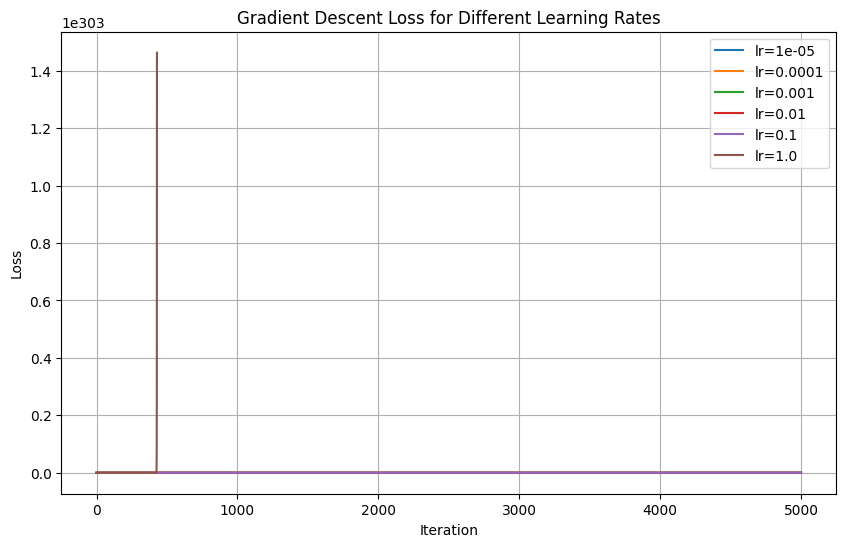

In [43]:
plt.figure(figsize=(10, 6))

for lr in learning_rates:
    plt.plot(
        gd_results[lr]["losses"],
        label=f"lr={lr}"
    )

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Gradient Descent Loss for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

1.2.3 Visualization

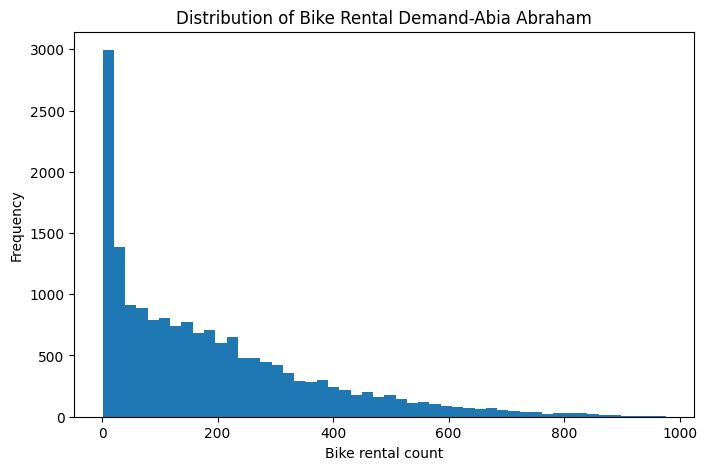

In [46]:
plt.figure(figsize=(8, 5))

plt.hist(df["cnt"], bins=50)

plt.xlabel("Bike rental count")
plt.ylabel("Frequency")
plt.title("Distribution of Bike Rental Demand-Abia Abraham")

plt.show()

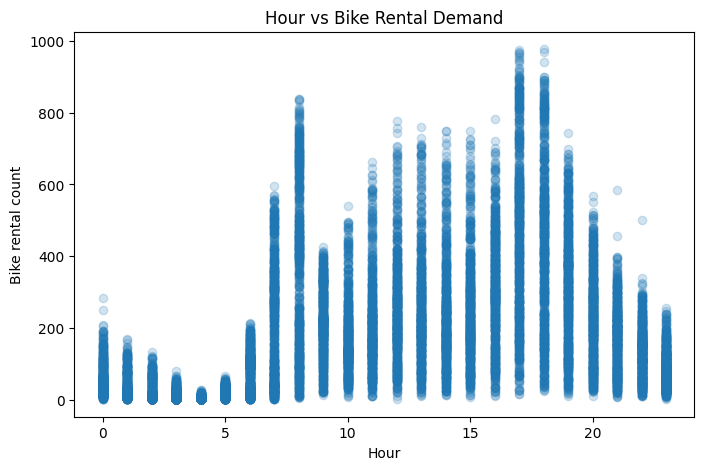

In [47]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["hr"],
    df["cnt"],
    alpha=0.2
)

plt.xlabel("Hour")
plt.ylabel("Bike rental count")
plt.title("Hour vs Bike Rental Demand-Abia Abraham")

plt.show()

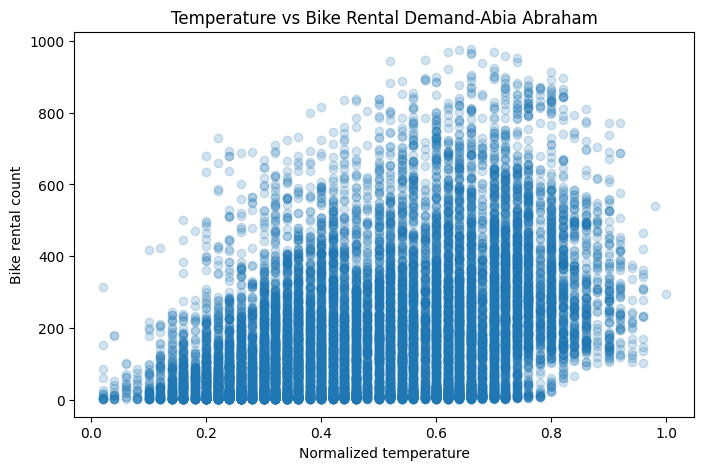

In [49]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["temp"],
    df["cnt"],
    alpha=0.2
)

plt.xlabel("Normalized temperature")
plt.ylabel("Bike rental count")
plt.title("Temperature vs Bike Rental Demand-Abia Abraham")

plt.show()

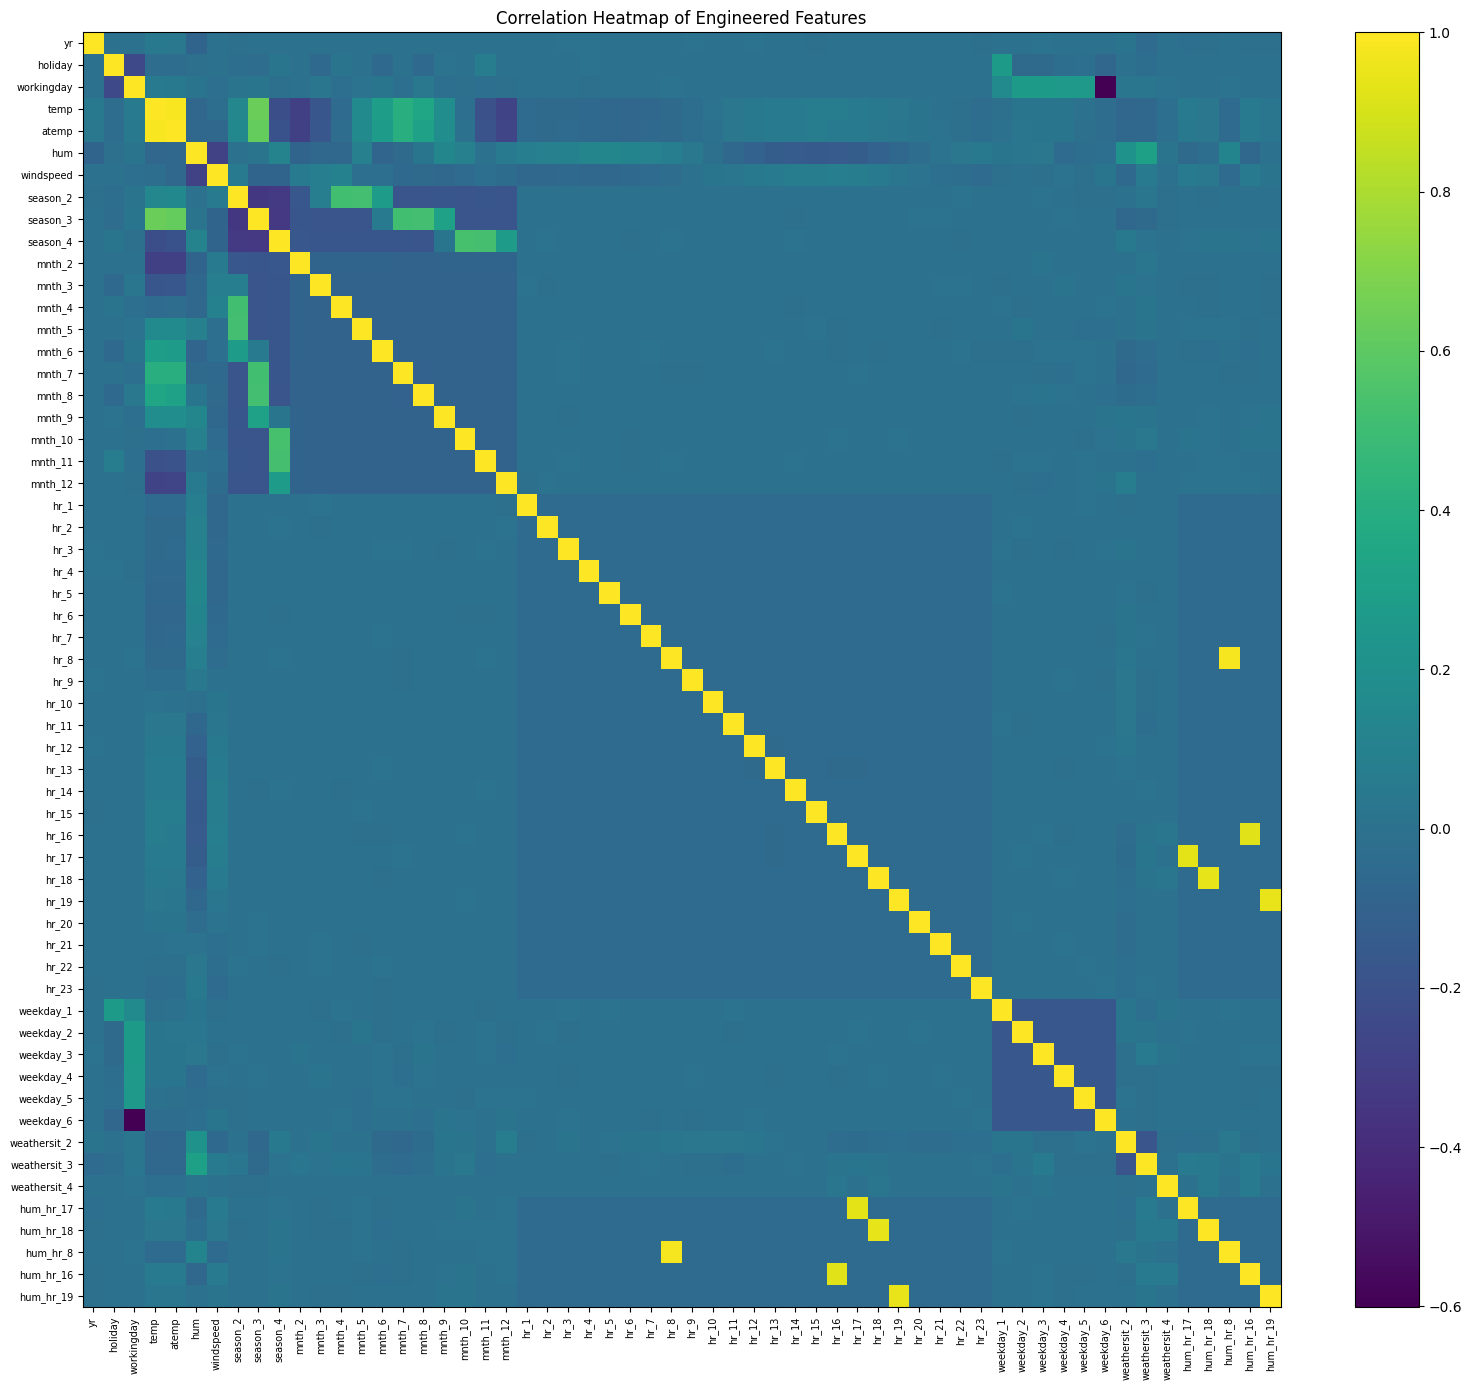

In [50]:
corr = X_train_eng.corr()

plt.figure(figsize=(16, 14))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns,
    fontsize=7
)

plt.title("Correlation Heatmap of Engineered Features")

plt.tight_layout()
plt.show()

In [ ]:
def engineer_features(data, top_5_hours):

    X = data.copy()

    categorical_columns = [
        "season",
        "mnth",
        "hr",
        "weekday",
        "weathersit"
    ]

    # One-hot encode categorical variables
    X = pd.get_dummies(
        X,
        columns=categorical_columns,
        drop_first=True,
        dtype=float
    )

    # Remove redundant workingday feature
    X = X.drop(columns=["workingday"])

    # Add five humidity × hour interactions
    for hour in top_5_hours:
        X[f"hum_hr_{hour}"] = (
            data["hum"] *
            (data["hr"] == hour).astype(float)
        )

    return X

In [ ]:
X_train_eng = engineer_features(
    X_train_std,
    top_5_hours
)

X_val_eng = engineer_features(
    X_val_std,
    top_5_hours
)

X_test_eng = engineer_features(
    X_test_std,
    top_5_hours
)

In [ ]:

train_columns = X_train_eng.columns

X_val_eng = X_val_eng.reindex(
    columns=train_columns,
    fill_value=0
)

X_test_eng = X_test_eng.reindex(
    columns=train_columns,
    fill_value=0
)

In [ ]:
print("Number of predictors:", X_train_eng.shape[1])

print("Train shape:", X_train_eng.shape)
print("Validation shape:", X_val_eng.shape)
print("Test shape:", X_test_eng.shape)

Number of predictors: 57
Train shape: (13903, 57)
Validation shape: (1738, 57)
Test shape: (1738, 57)


### 1.2 Standardization

The continuous features `temp`, `atemp`, `hum`, and `windspeed` were standardized using the transformation

$$
x'=\frac{x-\mu_{\text{train}}}{\sigma_{\text{train}}},
$$

where the mean and standard deviation were calculated exclusively from the training set. The resulting training-set statistics were: `temp` (\(\mu=0.497396,\sigma=0.193017\)), `atemp` (\(\mu=0.476183,\sigma=0.172308\)), `hum` (\(\mu=0.627011,\sigma=0.192801\)), and `windspeed` (\(\mu=0.189822,\sigma=0.122293\)).

The same training-set means and standard deviations were then applied to the validation and test sets. This prevents information from the validation or test sets from influencing the preprocessing step. After standardization, the continuous training features have approximately zero mean and unit standard deviation, while the validation and test features are not expected to have exactly zero mean or unit standard deviation because they are transformed using the training-set statistics.

The five humidity–time interaction terms were also constructed using the standardized humidity feature, so that the interaction coefficients represent the additional effect associated with a standardized change in humidity at the selected hours.


In [ ]:
print("Standardized training means:")
print(X_train_std[continuous_columns].mean())

print("\nStandardized training standard deviations:")
print(X_train_std[continuous_columns].std())

print("\nNumber of predictors:",
      X_train_eng.shape[1])

print("\nFinal matrix shapes:")
print(X_train_eng.shape)
print(X_val_eng.shape)
print(X_test_eng.shape)

Standardized training means:
temp        -2.555358e-19
atemp       -2.235938e-16
hum         -2.759786e-17
windspeed   -6.439501e-17
dtype: float64

Standardized training standard deviations:
temp         1.0
atemp        1.0
hum          1.0
windspeed    1.0
dtype: float64

Number of predictors: 58

Final matrix shapes:
(13903, 58)
(1738, 58)
(1738, 58)


In [ ]:
X_train_final = np.column_stack([
    np.ones(len(X_train_eng)),
    X_train_eng.values
])

X_val_final = np.column_stack([
    np.ones(len(X_val_eng)),
    X_val_eng.values
])

X_test_final = np.column_stack([
    np.ones(len(X_test_eng)),
    X_test_eng.values
])

In [ ]:
rank = np.linalg.matrix_rank(X_train_final)

print("Rank of X:", rank)
print("Number of columns:", X_train_final.shape[1])

Rank of X: 58
Number of columns: 58


In [ ]:

#calculation of condition no:
XTX = X_train_final.T @ X_train_final

condition_number = np.linalg.cond(XTX)

print("Condition number of X^T X:", condition_number)

Condition number of X^T X: 15237.324912039632


In [ ]:
#target vectors
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

y_train shape: (13903,)
y_val shape: (1738,)
y_test shape: (1738,)


In [ ]:
#implementation of the normal eq
def fit_normal_equation(X, y):

    XTX = X.T @ X
    XTy = X.T @ y

    w = np.linalg.solve(XTX, XTy)

    return w

In [ ]:
#fitting the model
w = fit_normal_equation(
    X_train_final,
    y_train
)

print("Coefficient vector shape:", w.shape)
print("First 10 coefficients:")
print(w[:10])

Coefficient vector shape: (58,)
First 10 coefficients:
[-25.50684043  86.00567924 -26.09552445  17.41896028  24.03050461
 -12.01871144  -3.34041065  34.00941327  30.98664903  68.52897384]


In [ ]:
y_train_pred = X_train_final @ w
y_val_pred = X_val_final @ w
y_test_pred = X_test_final @ w

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(
        np.mean((y_true - y_pred) ** 2)
    )

In [ ]:
train_rmse = rmse(y_train, y_train_pred)
val_rmse = rmse(y_val, y_val_pred)

print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Training RMSE: 101.63484265920624
Validation RMSE: 101.93232758861593


In [ ]:
w = fit_normal_equation(
    X_train_final,
    y_train
)

y_train_pred = X_train_final @ w
y_val_pred = X_val_final @ w

train_rmse = rmse(y_train, y_train_pred)
val_rmse = rmse(y_val, y_val_pred)

print("Coefficient vector shape:", w.shape)
print("Training RMSE:", train_rmse)
print("Validation RMSE:", val_rmse)

Coefficient vector shape: (58,)
Training RMSE: 101.63484265920624
Validation RMSE: 101.93232758861593


### Closed-Form Linear Regression

The final design matrix contained 58 columns, including the intercept. Since the feature-engineered design matrix was found to have full column rank after removing the redundant `workingday` representation, the least-squares coefficients were obtained by solving the normal equations

$$
(X^TX)w=X^Ty.
$$

Rather than explicitly computing \((X^TX)^{-1}\), the linear system was solved using a numerical linear-system solver. The resulting coefficient vector contained 58 parameters.

The model achieved a training RMSE of **101.635** and a validation RMSE of **101.932**. The difference between the two RMSE values was only approximately **0.30**, indicating a small train-validation performance gap. Thus, there is no strong evidence of substantial overfitting based on these results. However, the RMSE remains relatively large compared with the scale of the target variable, indicating that the linear model does not capture all of the variation in hourly bike rental demand.

The close agreement between training and validation RMSE suggests that the model's limitation is more likely related to the representational capacity of the linear model and the selected features than to severe overfitting.
